# Sentimental Analysis And location with USGS API

In [1]:
!pip install transformers datasets torch scikit-learn emoji langdetect


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import emoji

from langdetect import detect

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertForSequenceClassification
)
from torch.optim import AdamW # Corrected import path

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [3]:
train_df = pd.read_csv('2015_Nepal_Earthquake_train.tsv', sep='\t', encoding='latin-1')
dev_df = pd.read_csv('2015_Nepal_Earthquake_dev.tsv', sep='\t', encoding='latin-1')
test_df = pd.read_csv('2015_Nepal_Earthquake_test.tsv', sep='\t', encoding='latin-1')

train_df.columns = ["id","text","label"]
dev_df.columns = ["id","text","label"]
test_df.columns = ["id","text","label"]

df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

## Remove Conflicting tweets

In [4]:
conflicts = df.groupby("text")["label"].nunique()
conflict_texts = conflicts[conflicts > 1].index

df = df[~df["text"].isin(conflict_texts)]

print("After removing conflicts:", len(df))

After removing conflicts: 11530


**DataSet cleaning**

In [5]:
custom_stopwords = ["nepal", "earthquake", "quake", "rt"]

def remove_custom(text):
    # Ensuring text is a string to avoid attribute errors
    text = str(text)
    words = text.split()
    words = [w for w in words if w.lower() not in custom_stopwords]
    return " ".join(words)


df["clean_text"] = df["text"].apply(remove_custom)

In [6]:
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False



def clean_text(text):

    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # remove hashtags symbol but keep word
    text = re.sub(r'#', '', text)

    # remove RT
    text = re.sub(r'\brt\b', '', text)

    # remove html entities like &amp
    text = re.sub(r'&\w+;', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].apply(is_english)]
df = df[df["clean_text"].str.len() > 5]

print("After cleaning:", len(df))

After cleaning: 10796


In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ThinkPad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ThinkPad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
def is_english(text):

    try:
        return detect(text) == "en"
    except:
        return False

## VADER

In [9]:
!pip install nltk

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ThinkPad\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Priority/Urgency Detection

In [11]:
priority_words = ["help", "urgent", "rescue", "trapped", "need", "please", "emergency"]

def detect_urgency(text):
    
    text = str(text).lower() 

    return any(word in text for word in priority_words)


df["urgency"] = df["clean_text"].apply(detect_urgency)

**VADER Sentiment Labels**

In [12]:
!pip install vaderSentiment


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

negative_words = [
    "help","trapped","injured","dying","collapse","collapsed",
    "damage","destroyed","missing","urgent","emergency",
    "dead","death","casualties","panic","critical","bleeding"
]

positive_words = [
    "donation","aid","support","rescue","rescued",
    "safe","relief","volunteers","assistance",
    "survivors","recovered"
]

negative_phrases = [
    "need food","need water","need shelter"
]

positive_phrases = [
    "food distribution","water supply","shelter provided","medical help"
]


def vader_label(text):
    raw_text = text          
    text = text.lower()
    
    neg_score = 0
    pos_score = 0

    # Phrase matching
    for phrase in negative_phrases:
        if phrase in text:
            neg_score += 2

    for phrase in positive_phrases:
        if phrase in text:
            pos_score += 2

    # Word matching 
    words = text.split()

    for w in words:
        if w in negative_words:
            neg_score += 1
        if w in positive_words:
            pos_score += 1

    # If strong keyword sentiment
    if neg_score > pos_score:
        return 0  # negative
    elif pos_score > neg_score:
        return 1  # positive

    # If tie than use VADER
    score = analyzer.polarity_scores(raw_text)['compound']

    if score >= 0.05:
        return 1
    elif score <= -0.05:
        return 0
    else:
        return 2

In [14]:
df["sentiment_label"] = df["clean_text"].apply(vader_label)

**Train Test Split**

In [15]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["clean_text"],
    df["sentiment_label"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment_label"]
)

Loading Bert Tokenizer

In [16]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

Tokenization

In [17]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

**Dataset Class**

In [18]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

**Create DataLoaders**

In [19]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [23]:
from transformers import BertForSequenceClassification

# Initialize the model 
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

**Loading Bert Model**

Hyperparameter Tuning Setup

In [24]:
learning_rate = 2e-5
batch_size = 16
epochs = 5
weight_decay = 0.01

Training Arguments

In [22]:
from transformers import TrainingArguments

learning_rate = 2e-5
batch_size = 16
epochs = 5
weight_decay = 0.01

training_args = TrainingArguments(

    output_dir="./results",

    num_train_epochs=epochs,

    per_device_train_batch_size=batch_size,

    per_device_eval_batch_size=batch_size,

    eval_strategy="epoch", 

    save_strategy="epoch",

    learning_rate=learning_rate,

    weight_decay=weight_decay,

    load_best_model_at_end=True,

    logging_dir="./logs",

    logging_steps=50
)

**Evalution Metrics**

In [24]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F
import torch

def compute_metrics(pred):
    labels = pred.label_ids
    logits = pred.predictions
    
    # prediction
    preds = logits.argmax(-1) 
    
    # Simple probabilities 
    probs = F.softmax(torch.from_numpy(logits), dim=-1).numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs, multi_class='ovr')
    }

In [25]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [26]:
trainer.train()

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc Roc
1,0.399400,0.321940,0.891616,0.885226,0.975456
2,0.274100,0.250916,0.921260,0.918448,0.983857
3,0.177500,0.310886,0.920797,0.918193,0.982629
4,0.123100,0.371170,0.920333,0.916175,0.982338


C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=2160, training_loss=0.2788841700664273, metrics={'train_runtime': 47031.8873, 'train_samples_per_second': 0.918, 'train_steps_per_second': 0.057, 'total_flos': 2271195021828096.0, 'train_loss': 0.2788841700664273, 'epoch': 4.0})

In [27]:
predictions = trainer.predict(val_dataset)

#   predicted class indices
y_pred = predictions.predictions.argmax(-1)

# labels from the prediction object
test_labels = predictions.label_ids 


from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Accuracy:", accuracy_score(test_labels, y_pred))
print("F1 Score:", f1_score(test_labels, y_pred, average="macro"))
print(classification_report(test_labels, y_pred))

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.9212598425196851
F1 Score: 0.9184480904015536
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       786
           1       0.94      0.91      0.93       871
           2       0.91      0.89      0.90       502

    accuracy                           0.92      2159
   macro avg       0.92      0.92      0.92      2159
weighted avg       0.92      0.92      0.92      2159



In [51]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, 
    recall_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import LabelBinarizer

#  Run Predictions
predictions = trainer.predict(val_dataset)

# Extract Data 
y_logits = predictions.predictions
y_pred = y_logits.argmax(-1)
test_labels = predictions.label_ids

#  Calculate AUC-ROC 
lb = LabelBinarizer()
test_labels_bin = lb.fit_transform(test_labels)

# Applying softmax to logits to get probabilities for the AUC-ROC
y_probs = np.exp(y_logits) / np.sum(np.exp(y_logits), axis=-1, keepdims=True)

# Macro-averaged AUC-ROC
auc_roc = roc_auc_score(test_labels_bin, y_probs, multi_class='ovr', average='macro')

# Calculate Precision and Recall
precision = precision_score(test_labels, y_pred, average='macro')
recall = recall_score(test_labels, y_pred, average='macro')

# Professional Output
print(f" BERT Sentiment Analysis Results ")
print(f"Accuracy:  {accuracy_score(test_labels, y_pred):.4f}")
print(f"Precision: {precision:.4f} ")
print(f"Recall:    {recall:.4f} (Sensitivity to sentiment)")
print(f"F1 Score:  {f1_score(test_labels, y_pred, average='macro'):.4f}")
print(f"AUC-ROC:   {auc_roc:.4f} (Class separation performance)")
print("\n Detailed Classification Report ")
print(classification_report(test_labels, y_pred, target_names=lb.classes_.astype(str)))

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


--- BERT Sentiment Analysis Results ---
Accuracy:  0.9213
Precision: 0.9190 (Reliability of sentiment flags)
Recall:    0.9185 (Sensitivity to sentiment)
F1 Score:  0.9184
AUC-ROC:   0.9839 (Class separation performance)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       786
           1       0.94      0.91      0.93       871
           2       0.91      0.89      0.90       502

    accuracy                           0.92      2159
   macro avg       0.92      0.92      0.92      2159
weighted avg       0.92      0.92      0.92      2159



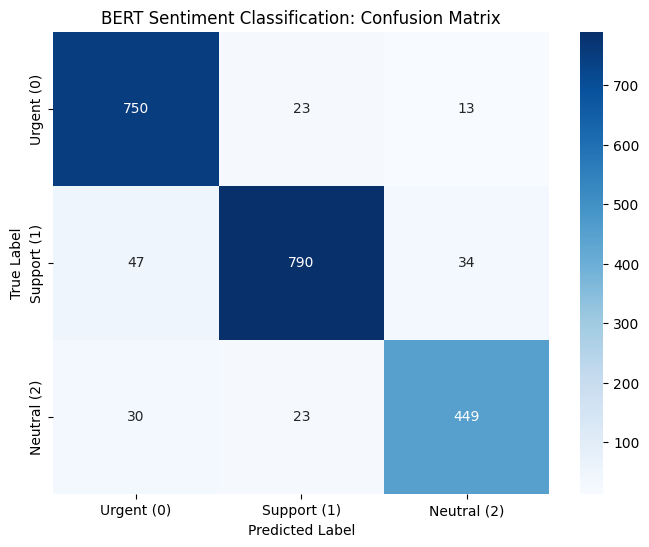

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(test_labels, y_pred)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Urgent (0)', 'Support (1)', 'Neutral (2)'],
            yticklabels=['Urgent (0)', 'Support (1)', 'Neutral (2)'])

plt.title('BERT Sentiment Classification: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [29]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Adding domain-specific words

custom_stops = {'nepal', 'nepalearthquake', 'earthquake', 'in', 'is', 'to', 'the'}
stop_words.update(custom_stops)

def get_top_words(df, label, n=10):
    # Filter text by label
    text_list = df[df['sentiment_label'] == label]['clean_text'].astype(str).tolist()
    
    # filter out stop words
    all_words = []
    for text in text_list:
        words = text.lower().split()
        # Only keep the word if it's not in our stop_word set
        filtered_words = [w for w in words if w not in stop_words and len(w) > 2]
        all_words.extend(filtered_words)
    
    return Counter(all_words).most_common(n)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ThinkPad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


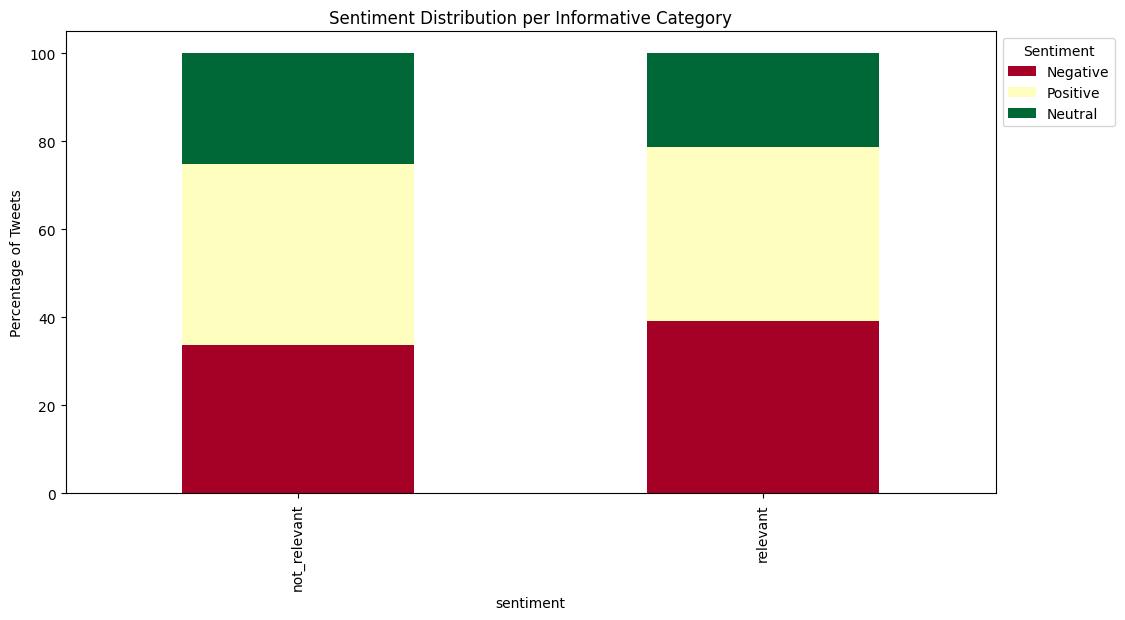

In [31]:

sentiment_topic_dist = pd.crosstab(df['label'], df['sentiment_label'], normalize='index') * 100

sentiment_topic_dist.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='RdYlGn')
plt.title("Sentiment Distribution per Informative Category")
plt.ylabel("Percentage of Tweets")
plt.xlabel("sentiment")
plt.legend(title="Sentiment", labels=['Negative', 'Positive', 'Neutral'], bbox_to_anchor=(1, 1))
plt.show()

C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_24516\4265668883.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment_label', data=df, palette='viridis')


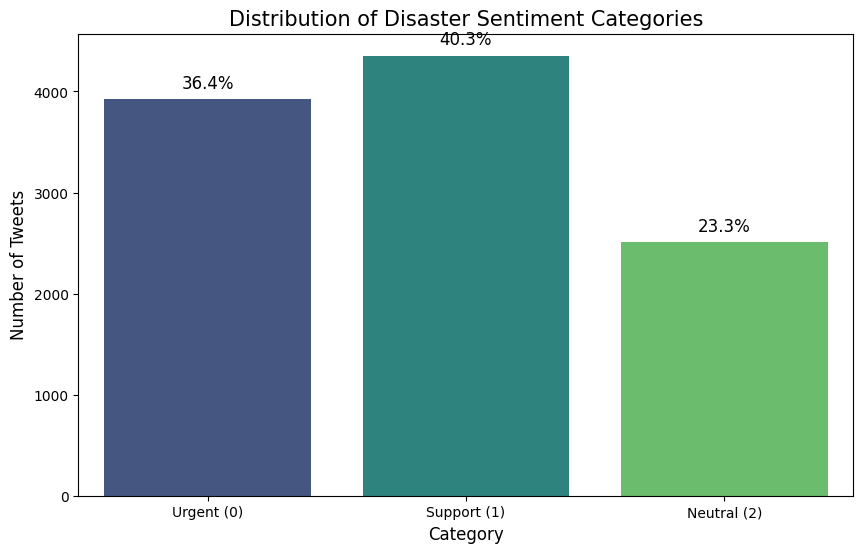

--- Sentiment Distribution Stats ---
Urgent (0): 3926 tweets (36.4%)
Support (1): 4354 tweets (40.3%)
Neutral (2): 2511 tweets (23.3%)


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution counts
distribution = df['sentiment_label'].value_counts().sort_index()
labels = ['Urgent (0)', 'Support (1)', 'Neutral (2)']

# Create the visualization
plt.figure(figsize=(10, 6))'
ax = sns.countplot(x='sentiment_label', data=df, palette='viridis')

#  Adding formatting
plt.title('Distribution of Disaster Sentiment Categories', fontsize=15)
plt.xticks(ticks=[0, 1, 2], labels=labels)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

# Adding percentage labels
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = height + (total * 0.01) 
    ax.annotate(percentage, (x, y), ha='center', size=12)

plt.show()

# Print stats
print(" Sentiment Distribution Stats ")
for i, count in enumerate(distribution):
    print(f"{labels[i]}: {count} tweets ({100 * count / total:.1f}%)")

In [33]:
import pandas as pd

cross_tab = pd.crosstab(df["label"], df["sentiment_label"])

print(" Correlation: Original Label vs. New Sentiment ")
print(cross_tab)

--- Correlation: Original Label vs. New Sentiment ---
sentiment_label     0     1     2
label                            
not_relevant     1891  2299  1409
relevant         2035  2055  1102


In [34]:
print(df.columns)

Index(['id', 'text', 'label', 'clean_text', 'urgency', 'sentiment_label'], dtype='str')


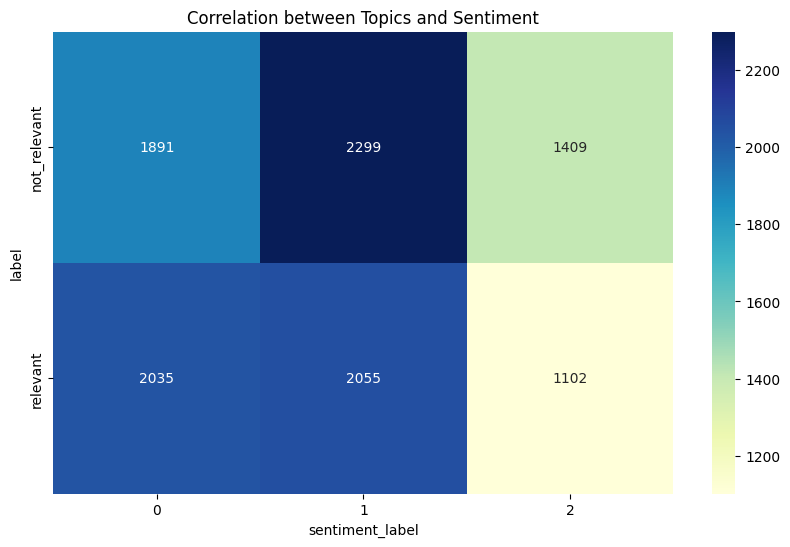

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(df["label"], df["sentiment_label"])

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Correlation between Topics and Sentiment')
plt.show()

In [36]:
pd.crosstab(df["label"], df["sentiment_label"])

sentiment_label,0,1,2
label,,,
not_relevant,1891,2299,1409
relevant,2035,2055,1102


In [37]:
pd.crosstab(df["label"], df["urgency"])

urgency,False,True
label,,
not_relevant,4797,802
relevant,3879,1313


## Since BERT Model have the highest value, now its perfect time to extract the location 

# Location Extraction

Here Named Entity Recognition (NER) is used to automatically identify and extract geographical locations

In [25]:
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_locations_ai(text):
    doc = nlp(str(text))
    # Automatically find Geopolitical Entities (GPE) and Locations (LOC)
    locations = [ent.text for ent in doc.ents if ent.label_ in ["GPE", "LOC"]]
    return list(set(locations))

df["locations"] = df["text"].apply(extract_locations_ai)

In [26]:
# Filtering and print only rows where a location was found
for loc_list in df[df['locations'].map(len) > 0]['locations']:
    print(", ".join(loc_list))

Lamjung
Kathmandu
Israel, Nepal
Nepal
Nepal
Bhutan
Nepal, Kathmandu
eveâ
China, Katmandu
Nepal
Nepal
Nepal
Nepal
Nepal
Hindon, Nepal, Kathmandu, UP
South Africa
UK
China, Nepal, India
India, Nepal
Atlanta, Nepal
Nepal
France
Nepal, India
Nepal
Nepal
Portland, Utah, Colorado
Nepal
Nepal
Taiwan, Nepal
Hexayurt, Nepal
Helambu, Melamchi Ghyang
Nepal
Nepal
The Bay here
Nepal, India
Nepal
Nepal
Nepal
Plano, Mount Everest
Nepal
Mt. Everest
Mabuhay
India
Pakistan
Nepal
Kathmandu
Nepal, Pakistan
Bangkok, Kathmandu
Nepal
Nepal
Nepal
Nepal
Ruins, Bhaktapur
Nepal
India
China, Nepal
India
UK
Nepal
Kathmandu
Everest
Gurkhas, Britain
Nepal
Nepali, Malaysia
Nepal
New York
Nepal
Nepal
Nepal
Kathmandu
Nepal
Israel, Gaza
Mt. Everest
Nepal
Asia
Kathmandu, Pokra
Nepal
Nepal
MD
Nepal
US, Nepal
Nepal, Georgia
Nepal
Nepal
ktm, SANKHA PARK
Nepal, Delhi
Nepal
Nepal
Nepal, Delhi, Safdarjung
Everest Base Camp
Kathmandu
India
Kathmandu
Yemen, Iran, Nepal
Hindan
Nepal
Nepal
RT, Nepal, VA
Nepal
Nepal
Nepal
Nepal
Ne

In [75]:
from collections import Counter

# Flatten the list of lists into a single list 
all_locations = [loc for loc_list in df['locations'] for loc in loc_list]

# Count frequencies
location_counts = Counter(all_locations)

# Get the most frequent location
if location_counts:
    most_common_loc, frequency = location_counts.most_common(1)[0]
    print(f"Most Frequent Location: {most_common_loc} (Found {frequency} times)")
else:
    print("No locations found.")

#  To see the top 10
print("\nTop 10 Locations:")
for loc, count in location_counts.most_common(10):
    print(f"{loc}: {count}")

Most Frequent Location: Nepal (Found 2075 times)

Top 10 Locations:
Nepal: 2075
India: 334
Kathmandu: 291
Baltimore: 162
Everest: 83
RT: 59
Israel: 58
China: 58
US: 46
UK: 42


### This is not enough, we need more dyanmic method to extract the location.So, we connect with the United States Geological Survey (USGS) API, to extract the epicenter

In [76]:
## this shows there is mamny noisy location to be filtered out

## Setting up Epicenter and Radius:: Hybrid API Approach

In [27]:
# First connecting to the United States Geological Survey (USGS) API.

## This is automated system only we need to put the details of the eaarthquake

In [28]:
import requests

def get_nepal_epicenter_automated(date_iso):
    # Nepal Bounding Box to avoid global noise 
    url = (
        f"https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson"
        f"&starttime={date_iso}&endtime={date_iso}T23:59:59"
        f"&minmagnitude=6.0"
        f"&minlatitude=26&maxlatitude=31"
        f"&minlongitude=80&maxlongitude=89"
    )
    
    try:
        response = requests.get(url).json()
        if not response['features']:
            print("No major earthquake found in the Nepal bounding box.")
            return None
        
        event = response['features'][0]
        coords = event['geometry']['coordinates'] # this is longitude, latitude
        place = event['properties']['place']
        
        print(f" GEOSPATIAL ANCHOR ESTABLISHED ")
        print(f"Epicenter: {place}")
        print(f"Coordinates: ({coords[1]}, {coords[0]})")
        return (coords[1], coords[0])
    
    except Exception as e:
        print(f"API Error: {e}")
        return None

# Here the Earthquake date is neeed and the date of the earthquake April 25, 2015 
EVENT_DATE = "2015-04-25"
epicenter_coords = get_nepal_epicenter_automated(EVENT_DATE)

 GEOSPATIAL ANCHOR ESTABLISHED 
Epicenter: 71 km NNE of Bharatpur, Nepal
Coordinates: (28.2244, 84.8216)


## We have to Geocde the location that are in the dataset

In [29]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="nepal_disaster_analysis")

#  Get all unique location names 
unique_locs = df.explode('locations')['locations'].dropna().unique()

#  Convert names to coordinates
loc_coords = {}
print("Geocoding verified locations...")
for name in unique_locs:
    try:
        # We append ', Nepal' to ensure the AI stays in the study region
        location = geolocator.geocode(f"{name}, Nepal", timeout=10)
        if location:
            loc_coords[name] = (location.latitude, location.longitude)
        time.sleep(1) # Nominatim's 1-second limit
    except:
        continue

Geocoding verified locations...


## Visualising the Finding nearest Places from epicenter

## This help to enusure that Geotagged location are correct

In [31]:
import folium
from folium.plugins import MarkerCluster

# Initializing Map at Epicenter
m = folium.Map(location=[epicenter_coords[0], epicenter_coords[1]], zoom_start=8)

# Adding Epicenter Marker
folium.Marker(
    location=[epicenter_coords[0], epicenter_coords[1]],
    popup="<b>Epicenter:</b> 71 km NNE of Bharatpur",
    icon=folium.Icon(color='red', icon='star')
).add_to(m)

#  Adding 100km Boundary (using 100,000 meters)
folium.Circle(
    location=[epicenter_coords[0], epicenter_coords[1]],
    radius=100000, 
    color='crimson',
    fill=True,
    fill_opacity=0.1,
    popup="100km Dynamic Impact Zone"
).add_to(m)


marker_cluster = MarkerCluster().add_to(m)

for name, coords in loc_coords.items():
    folium.CircleMarker(
        location=[coords[0], coords[1]],
        radius=5,
        popup=f"AI Detected: {name}",
        color="blue",
        fill=True,
        fill_color="blue"
    ).add_to(marker_cluster)

# Display Map
m

## Finding the closest places near the epicenter

In [32]:
import requests
import time

def get_villages_near_epicenter(lat, lon, radius_km=15):
    # Using a more robust Kumi Systems 
    overpass_url = "https://overpass.kumi.systems/api/interpreter"
    
    query = f"""
    [out:json][timeout:25];
    (
      node["place"~"village|hamlet|town"](around:{radius_km * 1000},{lat},{lon});
    );
    out body;
    """
    
    try:
        response = requests.get(overpass_url, params={'data': query})
        
      
        if response.status_code != 200:
            print(f"Server Error: {response.status_code}")
            return {}

     
        data = response.json()
        
        nearby_places = {}
        for element in data.get('elements', []):
            name = element.get('tags', {}).get('name')
            if name:
                nearby_places[name] = [element['lat'], element['lon']]
                
        return nearby_places

    except requests.exceptions.JSONDecodeError:
        print("Error: The server returned an invalid response (likely HTML instead of JSON).")
        print("This often happens if the Overpass API is overloaded. Try again in a few seconds.")
        return {}
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return {}

# Dynamically fetch villages near dfr coordinates
epicenter_lat, epicenter_lon = 28.2244, 84.8216
dynamic_villages = get_villages_near_epicenter(epicenter_lat, epicenter_lon, radius_km=15)

if dynamic_villages:
    print(f"Found {len(dynamic_villages)} villages near the epicenter.")
else:
    print("No villages found or API call failed.")

Found 24 villages near the epicenter.


In [33]:
#  Adding Dynamic Markers to the Map
for v_name, v_coords in dynamic_villages.items():
    # Using a different color/icon to distinguish villages from tweet locations
    folium.Marker(
        location=v_coords,
        popup=f"<b>Village:</b> {v_name}<br>Impacted Settlement",
        icon=folium.Icon(color='green', icon='home', prefix='fa')
    ).add_to(m)


## Geocoded Location

In [79]:
import pandas as pd

#Stop-word list
location_blacklist = {
    'nepal', 'nepali', 'ruins', 'asia', 'earthquake', 'hospital', 'emergency',
    'us', 'usa', 'france', 'israel', 'india', 'china', 'pakistan', 'uk', 'bangkok'
}

all_seen_locations = set()
nepal_locations_list = []

# Extract locations from dataset (NER + Geocoding)
for _, row in nepal_relevant_df.iterrows():
    for loc in row['locations']:
        loc_lower = loc.lower().strip()

        if loc_lower not in location_blacklist and loc in loc_coords:

            lat, lon = loc_coords[loc]

            # Nepal bounding box
            if 26.0 <= lat <= 30.5 and 80.0 <= lon <= 89.0:

                if loc_lower not in all_seen_locations:
                    nepal_locations_list.append({
                        'Location Name': loc,
                        'Latitude': round(lat, 4),
                        'Longitude': round(lon, 4),
                        'Source': 'NER',
                        'Example Context': row['text'][:80] + "..."
                    })
                    all_seen_locations.add(loc_lower)

# dynamic villages (English village list)
for village, coords in dynamic_villages.items():
    village_lower = village.lower().strip()

    if village_lower not in all_seen_locations:
        nepal_locations_list.append({
            'Location Name': village,
            'Latitude': round(coords[0], 4),
            'Longitude': round(coords[1], 4),
            'Source': 'Nearby Village',
            'Example Context': 'From Overpass API (Epicenter proximity)'
        })
        all_seen_locations.add(village_lower)

# DataFrame
nepal_places_df = pd.DataFrame(nepal_locations_list)

#  Final Output
print(f" TOTAL UNIQUE LOCATIONS (NER with Villages): {len(nepal_places_df)} ")
print(
    nepal_places_df[
        ['Location Name', 'Latitude', 'Longitude', 'Source']
    ].to_string(index=False)
)

 TOTAL UNIQUE LOCATIONS (NER with Villages): 160 
    Location Name  Latitude  Longitude         Source
          Lamjung   28.2876    84.4189            NER
        Kathmandu   27.7083    85.3206            NER
         Katmandu   27.7083    85.3206            NER
               UP   26.6959    83.1107            NER
         Portland   28.2104    83.9576            NER
          Helambu   28.0060    85.5313            NER
  Melamchi Ghyang   28.0177    85.5233            NER
        Bhaktapur   27.6711    85.4262            NER
          Gurkhas   27.7407    85.3265            NER
            Pokra   27.4340    85.7450            NER
              ktm   27.6939    85.3582            NER
      SANKHA PARK   28.3075    82.2441            NER
             Iran   27.7112    85.3189            NER
     Everest Base   27.9974    86.8473            NER
   Bamboo Village   28.2543    84.3711            NER
            Tibet   27.9735    85.9642            NER
            Bipin   27.7004    8

In [39]:
from geopy.distance import geodesic

def filter_nepal_tweets(df, epicenter, max_km=100):
    verified_tweets = []
    
    for index, row in df.iterrows():
        # Check if the AI found any locations in this tweet
        if not row['locations']:
            continue
            
        in_zone = False
        # Check every location found in the tweet
        for loc_name in row['locations']:
            # Use the coordinates we saved in loc_coords dictionary
            if loc_name in loc_coords:
                tweet_loc = loc_coords[loc_name]
                # Calculate distance between Epicenter and Tweet Location
                distance = geodesic(epicenter, tweet_loc).km
                
                if distance <= max_km:
                    in_zone = True
                    break # One valid location in the zone is enough
        
        if in_zone:
            verified_tweets.append(row)
            
    return pd.DataFrame(verified_tweets)

# Applying the filter
nepal_relevant_df = filter_nepal_tweets(df, epicenter_coords, max_km=100)

# Display the results
print(f"Found {len(nepal_relevant_df)} tweets within the 100km Nepal impact zone.")
print(nepal_relevant_df[['text', 'locations']].head())

Found 2545 tweets within the 100km Nepal impact zone.
                                                text        locations
1  @jonsnowC4 So have we; read our friends blog f...        [Lamjung]
3  @shilpaanand they've managed to reach Kathmand...      [Kathmandu]
4  Israel Sending Aid Teams to Nepal After Quake:...  [Israel, Nepal]
6  British archeologist 'terrified' after narrowl...          [Nepal]
7  RT @nrarmour: More kudos to 2010 Olympic champ...          [Nepal]


In [77]:
import pandas as pd

# Defining the Stop-Word list for non-geographic noise
location_blacklist = {
    'nepal', 'nepali', 'ruins', 'asia', 'earthquake', 'hospital', 'emergency','iran', 'earth'
    'us', 'usa', 'france', 'israel', 'india', 'china', 'pakistan', 'uk', 'bangkok'
}

# Iterating through dfr entire dataframe to capture all unique points
all_seen_locations = set()
nepal_locations_list = []

for _, row in nepal_relevant_df.iterrows():
    for loc in row['locations']:
        loc_lower = loc.lower().strip()
        
        # Validation Layer 1: Blacklist & Geocode existence
        if loc_lower not in location_blacklist and loc in loc_coords:
            
            # Validation Layer 2: Geospatial Bounding Box for Nepal

            lat, lon = loc_coords[loc]
            if 26.0 <= lat <= 30.5 and 80.0 <= lon <= 89.0:
                
                if loc_lower not in all_seen_locations:
                    nepal_locations_list.append({
                        'Location Name': loc,
                        'Latitude': round(lat, 4),
                        'Longitude': round(lon, 4),
                        'Example Context': row['text'][:80] + "..." 
                    })
                    all_seen_locations.add(loc_lower)

#result table
nepal_places_df = pd.DataFrame(nepal_locations_list)

# Print the final list
print(f" TOTAL UNIQUE LOCATIONS IDENTIFIED WITHIN NEPAL: {len(nepal_places_df)} ")
print(nepal_places_df[['Location Name', 'Latitude', 'Longitude']].to_string(index=False))

 TOTAL UNIQUE LOCATIONS IDENTIFIED WITHIN NEPAL: 135 
    Location Name  Latitude  Longitude
          Lamjung   28.2876    84.4189
        Kathmandu   27.7083    85.3206
         Katmandu   27.7083    85.3206
               UP   26.6959    83.1107
         Portland   28.2104    83.9576
          Helambu   28.0060    85.5313
  Melamchi Ghyang   28.0177    85.5233
        Bhaktapur   27.6711    85.4262
          Gurkhas   27.7407    85.3265
            Pokra   27.4340    85.7450
              ktm   27.6939    85.3582
      SANKHA PARK   28.3075    82.2441
     Everest Base   27.9974    86.8473
   Bamboo Village   28.2543    84.3711
            Tibet   27.9735    85.9642
            Bipin   27.7004    85.3415
           Queens   27.6867    84.4397
          Koirala   27.5885    85.5124
             Modi   28.3108    83.7163
         Langtang   28.2158    85.5090
            Agnes   26.6690    87.7015
  Gorkha District   27.9950    84.6280
          Everest   27.9881    86.9252
          

In [41]:
# Improved Geocoding with Administrative Filtering
def get_strict_location(name, geolocator):
    try:
        # We search specifically for the name within Nepal
        location = geolocator.geocode(f"{name}, Nepal", exactly_one=True, addressdetails=True)
        
        if location:
            address = location.raw.get('address', {})
    
            country = address.get('country', '')
            if country == 'Nepal':
                return (location.latitude, location.longitude)
    except:
        return None
    return None

In [43]:
import pandas as pd

# 'Stop-Word' Location List to remove non-geographic noise
location_blacklist = {
    'nepal', 'nepali', 'ruins', 'asia', 'earthquake', 'hospital', 'emergency',
    'us', 'usa', 'france', 'israel', 'india', 'china', 'pakistan', 'uk', 'bangkok'
}


seen_locations = set()
cleaned_sample = []

for _, row in nepal_relevant_df.iterrows():
    for loc in row['locations']:
        loc_lower = loc.lower().strip()
        
        # Checkingg against blacklist and ensure it was geocoded successfully
        if loc_lower not in location_blacklist and loc in loc_coords:
            
            #if coordinates are within the realistic bounding box of Nepal 
            lat, lon = loc_coords[loc]
            if 26.0 <= lat <= 30.5 and 80.0 <= lon <= 89.0:
                
                if loc_lower not in seen_locations:
                    cleaned_sample.append({
                        '#': len(cleaned_sample) + 1,
                        'Verified Location': loc,
                        'GPS Coordinates': f"({round(lat, 4)}, {round(lon, 4)})",
                        'Representative Tweet Intelligence': row['text']
                    })
                    seen_locations.add(loc_lower)
                    break
    
    if len(cleaned_sample) >= 20:
        break

#  final DataFrame
final_table_df = pd.DataFrame(cleaned_sample)

# Setting display options
pd.set_option('display.max_colwidth', 80)
print(" GEOGRAPHICALLY VERIFIED DISASTER LOCATIONS TABLE ")
print(final_table_df.to_string(index=False))

 GEOGRAPHICALLY VERIFIED DISASTER LOCATIONS TABLE 
 # Verified Location    GPS Coordinates                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [247]:
import pandas as pd

#stopword location
location_blacklist = {
    'nepal', 'nepali', 'ruins', 'asia', 'earthquake', 'hospital', 'emergency',
    'us', 'usa', 'france', 'israel', 'india', 'china', 'pakistan', 'uk', 'bangkok', 'iran' ,'UP'
}

seen_locations = set()
diverse_sample = []

# Iterate through the dataframe with strict Nepal-only logic
for _, row in nepal_relevant_df.iterrows():
    for loc in row['locations']:
        loc_lower = loc.lower().strip()
        
        # Checkingg against naoise and 
        if loc_lower not in location_blacklist and loc in loc_coords:
            
            # COORDINATE FILTER: Strictly within Nepal's bounding box
            lat, lon = loc_coords[loc]
            if 26.0 <= lat <= 30.5 and 80.0 <= lon <= 89.0:
                
                if loc_lower not in seen_locations:
                    diverse_sample.append({
                        '#': len(diverse_sample) + 1,
                        'Verified Nepal Location': loc,
                        'GPS Coordinates': f"({round(lat, 4)}, {round(lon, 4)})"
                    })
                    seen_locations.add(loc_lower)
                    break 
            
    if len(diverse_sample) >= 20:
        break

#  Display the result as a clean table
cleaned_places_df = pd.DataFrame(diverse_sample)
print(" CLEANED LIST OF PLACES INSIDE NEPAL ")
print(cleaned_places_df.to_string(index=False))

 CLEANED LIST OF PLACES INSIDE NEPAL 
 # Verified Nepal Location    GPS Coordinates
 1                 Lamjung (28.2876, 84.4189)
 2               Kathmandu (27.7083, 85.3206)
 3                Katmandu (27.7083, 85.3206)
 4                      UP (26.6959, 83.1107)
 5                Portland (28.2104, 83.9576)
 6                 Helambu  (28.006, 85.5313)
 7               Bhaktapur (27.6711, 85.4262)
 8                 Gurkhas (27.7407, 85.3265)
 9                   Pokra   (27.434, 85.745)
10                     ktm (27.6939, 85.3582)
11            Everest Base (27.9974, 86.8473)
12          Bamboo Village (28.2543, 84.3711)
13                   Tibet (27.9735, 85.9642)
14                   Bipin (27.7004, 85.3415)
15                  Queens (27.6867, 84.4397)
16                 Koirala (27.5885, 85.5124)
17                Langtang  (28.2158, 85.509)
18         Gorkha District   (27.995, 84.628)
19                 Everest (27.9881, 86.9252)
20                  Thamel (27.7167, 85.31

 here we may find few mistakes like portland; when actual location is in 'Pokhara'. Its largely due to having multiple locaiton namein a single tweets

## Let use see the close places near the Epicenter

In [254]:
# Extracting and print only the village names as a list
village_names_only = list(dynamic_villages.keys())

print(" Villages Near Epicenter ")
for i, name in enumerate(sorted(village_names_only), 1):
    print(f"{i}. {name}")

 Villages Near Epicenter 
1. Arkhet Bazar
2. Aruarbang
3. Baluwa
4. Barpak
5. Dharot
6. Dobhan
7. Ghyachok
8. Gumda
9. Kashigaun
10. Khorlabesi
11. Labsibot
12. Laprak
13. Lapu
14. Lapu Besi
15. Machhakhola
16. Mandre
17. Saurpani
18. Singhla
19. Tatopani
20. Thailidada
21. Thumi
22. Yamgaun
23. बसेरी
24. शिमजुनग


Since, we got plenty of the location from anlayis above now let us combine them in a list to further analysis

In [257]:
# 1. Define the master list of Nepal places
nepal_places = [
    "kathmandu", "bhaktapur", "lalitpur", "pokhara", "gorkha", "chitwan", 
    "lamjung", "sindhupalchok", "dhading", "nuwakot", "jumla", "biratnagar",
    "kavre", "kavrepalanchok", "dolakha", "rasuwa", "ramechhap", "makwanpur",
    "sindhuli", "okhaldhunga", "tanahu", "kaski", "syangja", "parbat",
    "barpak", "bharpak", "langtang", "namche", "everest", "base camp", 
    "kodari", "chautara", "bahrabise", "melamchi", "tatopani",
    "dharahara", "tudikhel", "lagankhel", "aru pokhari", "saurpani", 
    "laprak", "simjung", "ghyachok", "hansapur", "gumda", "uhiya", 
    "lho", "prok", "bihi", "chumchet", "chhekampar", "sirdibas", 
    "philim", "nyatola", "khorlabesi", "jagat", "salleri", "dyang", 
    "ghap", "namrung", "lihi", "sho", "samagaun", "samdo", 
    "dharapani", "manaslu base camp", "mu gompa", "arughat", 
    "sankha park", "sukedhara", "sitapaila", "jorpati", "tripureswor", 
    "ason", "birgunj", "butwal", "hetauda", "janakpur", "dharan", 
    "itahari", "manang", "mustang", "jomsom", "gosaikunda", "tilganga", 
    "boudhanath", "pashupatinath", "swayambhunath", "chomrong", "dhunche", 
    "charikot", "jiri", "panauti", "dhulikhel", "banepa", "lumbini", 
    "bhairahawa", "bharatpur", "arkhet bazar", "aruarbang", "baluwa", 
    "dobhan", "kashigaun", "labsibot", "lapu", "lapu besi", 
    "machhakhola", "singhla", "yamgaun","rasuwa", "makwanpur", "okhaldhunga", "patan", "swayambhunath", "basantapur", "chautara"
]

# Function to filter extracted locations using the master list
def filter_nepal_locations(loc_list):
    # Match lowercased extracted locations against lowercased master list
    return [loc for loc in loc_list if loc.lower().strip() in nepal_places]

# Apply the filter to dfr DataFrame
df["confirmed_locations"] = df["locations"].apply(filter_nepal_locations)

#Frequency Analysis of Confirmed Locations
from collections import Counter
all_confirmed = [loc for sublist in df["confirmed_locations"] for loc in sublist]
confirmed_counts = Counter(all_confirmed)

#  Output Results
print(f"Total unique Nepal locations detected: {len(confirmed_counts)}")
print("\nTop 10 High-Urgency Impacted Areas:")
for loc, count in confirmed_counts.most_common(10):
    print(f"{loc.title()}: {count} mentions")

Total unique Nepal locations detected: 50

Top 10 High-Urgency Impacted Areas:
Kathmandu: 541 mentions
Everest: 228 mentions
Gorkha: 57 mentions
Base Camp: 45 mentions
Langtang: 26 mentions
Bhaktapur: 25 mentions
Pokhara: 21 mentions
Patan: 18 mentions
Dharahara: 14 mentions
Lamjung: 8 mentions


## Priority

### Need

Here, is the keyword based rule engine, which automatically categorizes text into specific humanitarian categories such as like food, medical

In [258]:
need_keywords = {
    "food": ["food","hungry","rice","meal"],
    "water": ["water","thirst"],
    "medical": ["injured","hospital","medicine","doctor","blood"],
    "shelter": ["tent","shelter","homeless"],
    "rescue": ["trapped","rescue","help","save"],
    "donation": ["donate","donation","fund","support"]
}

def extract_need(text):
    text = text.lower()
    needs = []
    
    for need, words in need_keywords.items():
        for w in words:
            if w in text:
                needs.append(need)
                break
                
    return needs

df["needs"] = df["text"].apply(extract_need)

## Setting out the Location

In [288]:
def extract_location(text):
    text_lower = text.lower()
    locations = []
    
    # spaCy NER
    doc = nlp(str(text))
    for ent in doc.ents:
        if ent.label_ in ["GPE", "LOC"]:
            locations.append(ent.text)
    
    # Manual Nepal locations
    for place in nepal_places:
        if place in text_lower:
            locations.append(place)
    
    return list(set(locations))

df["locations"] = df["text"].apply(extract_location)

In [379]:
## Adding the nepal_place in the location

In [295]:
import re


nepal_places.sort(key=len, reverse=True)

#  a single optimized regex pattern
pattern = re.compile(r'\b(' + '|'.join(map(re.escape, nepal_places)) + r')\b', flags=re.IGNORECASE)

def extract_nepal_only_fixed(text):
    if not isinstance(text, str):
        return []
    
    matches = pattern.findall(text.lower())
    return list(set(matches))

# apply the fixed function
df["nepal_location"] = df["text"].apply(extract_nepal_only_fixed)

In [380]:
# Fixing location names miswritten

In [357]:
import re


location_aliases = {
    "larpark": "Laprak",
    "lapu besi": "Lapubesi",
    "bharpak": "Barpak",
    "kavrepalanchok": "Kavre",
    "Pokhara": "Pokra"
}

# Master Lookup 

master_lookup = {p.lower(): p for p in nepal_places}
for alias, standard in location_aliases.items():
    master_lookup[alias.lower()] = standard

#  Build the Search List 
all_search_terms = list(set(nepal_places + list(location_aliases.keys())))
all_search_terms.sort(key=len, reverse=True) 

# Optimized Regex Union
pattern = re.compile(r'\b(' + '|'.join(map(re.escape, all_search_terms)) + r')\b', flags=re.IGNORECASE)

def extract_and_normalize(text):
    if not isinstance(text, str):
        return []
    
    # Find all mentions 
    matches = pattern.findall(text.lower())
    
    # Translate found terms 
    standardized = [master_lookup[m.lower()] for m in matches if m.lower() in master_lookup]
    
    return list(set(standardized))

#  Execute
df["locations"] = df["text"].apply(extract_and_normalize)

In [358]:
import re

nepal_set = {p.lower(): p for p in nepal_places}

# Optimized Regex Union

pattern = re.compile(r'\b(' + '|'.join(map(re.escape, nepal_places)) + r')\b', flags=re.IGNORECASE)

def replace_with_standard(text):
    if not isinstance(text, str):
        return []
    
    # Find all matches in the text
    matches = pattern.findall(text.lower())
    
    standardized = [nepal_set[m.lower()] for m in matches if m.lower() in nepal_set]
    
    return list(set(standardized))

#location columns
df["locations"] = df["text"].apply(replace_with_standard)

## Severity Detection

In [359]:
import re

high_severity_words = [
    "dead","killed","death","collapsed","trapped","buried",
    "critical","severe","destroyed","missing","dying",
    "under rubble","serious","bleeding","unconscious"
]

medium_severity_words = [
    "injured","damage","damaged","blocked","shortage",
    "no water","no food","need shelter","homeless",
    "electricity out","roads blocked","network down"
]

def severity_level(text):
    text = text.lower()
    
    # High severity keywords
    if any(w in text for w in high_severity_words):
        return "high"
    
    # Medium severity keywords
    elif any(w in text for w in medium_severity_words):
        return "medium"
    
    # Numbers of people affected
    numbers = re.findall(r'\d+', text)
    if len(numbers) > 0:
        num = int(numbers[0])
        if num >= 50:
            return "high"
        elif num >= 10:
            return "medium"
    
    return "low"

df["severity"] = df["text"].apply(severity_level)

## Temporal urgency

In [360]:
temporal_words = [
    "now","immediately","asap","urgent","quick",
    "fast","right now","minutes","seconds"
]

def temporal_urgency(text):
    text = text.lower()
    return int(any(w in text for w in temporal_words))

df["temporal_urgency"] = df["text"].apply(temporal_urgency)

## First Person Detection

In [361]:
first_person_words = ["i","me","my","we","us","our"]

def first_person(text):
    words = text.lower().split()
    return int(any(w in words for w in first_person_words))

df["first_person"] = df["text"].apply(first_person)

## Panic punctuation / typography

In [362]:
def punctuation_stress(text):
    if "!!!" in text or "???" in text:
        return 1
    if text.isupper():
        return 1
    return 0

df["punctuation_stress"] = df["text"].apply(punctuation_stress)

In [363]:
## Information having phone number and distance of certain location is more important

In [364]:
import re

def phone_number(text):
    return int(bool(re.search(r'\d{7,}', text)))

df["phone_number"] = df["text"].apply(phone_number)

In [365]:
def distance_info(text):
    return int("km" in text.lower())

df["distance_info"] = df["text"].apply(distance_info)

In [366]:
## Infrastructure Words: where infrastructure damage have been done

In [367]:
infra_words = [
    "roads blocked","electricity out","phone lines down",
    "network down","bridge collapsed"
]

def infrastructure_failure(text):
    text = text.lower()
    return int(any(w in text for w in infra_words))

df["infra_failure"] = df["text"].apply(infrastructure_failure)

In [368]:
## Adding Actionable Feature

In [369]:
action_words = [
    "need","help","send","require","looking for",
    "please","anyone","contact","phone",
    "stuck","trapped","rescue","deliver",
    "urgent","asap"
]

def actionable_request(text):
    text = text.lower()
    return int(any(w in text for w in action_words))

df["actionable"] = df["text"].apply(actionable_request)

In [370]:
## News Information is not helpful as they are sharing past information

In [371]:
news_words = [
    "killed","magnitude","reports","news","update",
    "photo","video","story","rescued","death toll",
    "breaking","media","reporter","ap","bbc","cnn",
    "earthquake strikes","according to","via", "isreal"
]

def news_tweet(text):
    text = text.lower()
    return int(any(w in text for w in news_words))

df["news"] = df["text"].apply(news_tweet)

## Actionable noun: that shows someone needs help

In [372]:
actionable_words = [
    "rubble","debris","collapsed","trapped","buried",
    "blood","bleeding","unconscious","ambulance",
    "dying","oxygen","hospital"
]

def actionable_nouns(text):
    text = text.lower()
    return int(any(w in text for w in actionable_words))

df["actionable_nouns"] = df["text"].apply(actionable_nouns)

## Numbers like people trapped etc

In [373]:
# Extracting and print only the village names as a list
village_names_only = list(dynamic_villages.keys())

print(" Villages Near Epicenter ")
for i, name in enumerate(sorted(village_names_only), 1):
    print(f"{i}. {name}")

 Villages Near Epicenter 
1. Arkhet Bazar
2. Aruarbang
3. Baluwa
4. Barpak
5. Dharot
6. Dobhan
7. Ghyachok
8. Gumda
9. Kashigaun
10. Khorlabesi
11. Labsibot
12. Laprak
13. Lapu
14. Lapu Besi
15. Machhakhola
16. Mandre
17. Saurpani
18. Singhla
19. Tatopani
20. Thailidada
21. Thumi
22. Yamgaun
23. बसेरी
24. शिमजुनग


In [374]:
def count_villages(text):
    text = str(text).lower()
    return sum(
        1 for v in village_names_only
        if re.search(rf"\b{re.escape(v)}\b", text)
    )

df["village_count"] = df["text"].apply(count_villages)

## Distance

In [345]:
def detect_numbers(text):
    nums = re.findall(r'\d+', text)
    return len(nums)

df["numbers"] = df["text"].apply(detect_numbers)

## Infrastructure Failure

In [346]:
infra_words = [
    "roads blocked","electricity out","phone lines down",
    "network down","bridge collapsed"
]

def infrastructure_failure(text):
    text = text.lower()
    return int(any(w in text for w in infra_words))

df["infra_failure"] = df["text"].apply(infrastructure_failure)

## Environment Risk

In [347]:
env_words = ["rain","cold","night","dark", "no light"]

def environment_risk(text):
    text = text.lower()
    return int(any(w in text for w in env_words))

df["environment_risk"] = df["text"].apply(environment_risk)

## Determining the type of tweet

In [348]:
def tweet_type(text):
    text = text.lower()
    
    if any(w in text for w in ["trapped","stuck","help us","rescue","urgent","need help now"]):
        return "rescue"
    
    elif any(w in text for w in ["blood","injured","hospital","ambulance","medical"]):
        return "medical"
    
    elif any(w in text for w in ["food","water","tent","shelter","supplies"]):
        return "resource"
    
    elif any(w in text for w in ["sending","deliver","relief team","distribution"]):
        return "coordination"
    
    elif any(w in text for w in ["road blocked","electricity","network down","bridge"]):
        return "infrastructure"
    
    elif any(w in text for w in ["death toll","killed","magnitude","news","report"]):
        return "news"
    
    elif any(w in text for w in ["donate","donation","fund","support"]):
        return "donation"
    
    elif any(w in text for w in ["pray","bless","rip"]):
        return "awareness"
    
    elif "http" in text and "t.co" in text:
        return "spam"
    
    else:
        return "other"


In [349]:
df["tweet_type"] = df["text"].apply(tweet_type)

## Now Setting the priority

In [350]:
def priority_score(row):
    score = 0

    # .get() to avoid KeyErrors if columns are missing
    tweet_type = row.get("tweet_type", "other")
    severity = row.get("severity", "low")
    needs = row.get("needs", [])
    
    # Importance of the tweet type
    if tweet_type in ["rescue", "medical", "resource"]:
        score += 5
    elif tweet_type in ["coordination", "infrastructure"]:
        score += 3
    elif tweet_type in ["news", "donation", "awareness", "spam"]:
        score -= 4
    
    #  Severity
    if severity == "high":
        score += 4
    elif severity == "medium":
        score += 2
    
    #  Need
    if "rescue" in needs:
        score += 3
    if "medical" in needs:
        score += 3
    if "food" in needs or "water" in needs:
        score += 2

    #  Nearest location & Urgency
    score += row.get("village_count", 0) * 7
    score += row.get("temporal_urgency", 0) * 2
    score += row.get("distance_info", 0) * 2
    score += row.get("first_person", 0) * 2
    score += row.get("punctuation_stress", 0) * 1
    score += row.get("actionable_nouns", 0) * 3
    score += row.get("environment_risk", 0) * 2
    score += row.get("infra_failure", 0) * 2
    
    #  Number and contact
    score += min(row.get("numbers", 0), 5)
    score += row.get("phone_number", 0)
    
    # Reducing non-urgent news
    score -= row.get("news", 0) * 3
    
    return score

df["priority_score"] = df.apply(priority_score, axis=1)

## Setting Priority Score

In [351]:
def priority_level(score):
    if score >= 10:
        return "HIGH"
    elif score >= 5:
        return "MEDIUM"
    else:
        return "LOW"

df["priority"] = df["priority_score"].apply(priority_level)

## Convert into proiority Level

In [352]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [353]:
location_priority = df.explode("locations")

location_priority.groupby("locations")["priority_score"].sum().sort_values(ascending=False)

locations
kathmandu        877
gorkha           150
langtang         123
everest           85
pokhara           62
lagankhel         49
biratnagar        35
nuwakot           26
patan             23
dharahara         18
lalitpur          17
chitwan           17
jumla             16
rasuwa            15
parbat            13
charikot          10
birgunj            9
aru pokhari        9
bhaktapur          9
sukedhara          9
sankha park        8
namche             8
okhaldhunga        7
pashupatinath      7
gosaikunda         7
ason               6
bharpak            6
sho                5
melamchi           5
jorpati            5
chomrong           4
tripureswor        3
dhading            3
tudikhel           3
tilganga           3
butwal             2
tatopani           2
hetauda            2
dhunche            2
itahari            1
laprak             0
sindhuli          -2
sitapaila         -2
kavre             -3
boudhanath        -3
basantapur        -4
sindhupalchok     -5
bar

In [378]:
# Let us check the location frequency

In [375]:
from collections import Counter

#  Flatten the lists into a single list of all location mentions
all_locations = [loc for loc_list in df['locations'] for loc in loc_list]

# Count the frequencies using Counter
location_counts = Counter(all_locations)

# Converting to a DataFrame for clean display
location_freq_df = pd.DataFrame(
    location_counts.items(), 
    columns=['Location', 'Mention Count']
).sort_values(by='Mention Count', ascending=False)

#  Display the results
print("Top 20 Most Frequent Locations:")
print(location_freq_df.head(20).to_string(index=False))

Top 20 Most Frequent Locations:
     Location  Mention Count
    kathmandu            541
      everest            228
       gorkha             57
    base camp             45
     langtang             26
    bhaktapur             25
      pokhara             21
        patan             18
    dharahara             14
      lamjung              8
pashupatinath              7
       barpak              5
   basantapur              5
   biratnagar              4
      chitwan              4
sindhupalchok              4
      nuwakot              3
    lagankhel              3
      dhading              3
     lalitpur              3


In [354]:
# Displaying the top 100 results with the correct column names
df[[
    "text",
    "locations", 
    "needs",
    "severity",
    "temporal_urgency",
    "first_person",
    "phone_number",
    "priority_score"    
]].sort_values(by="priority_score", ascending=False).head(100)

,text,locations,needs,severity,temporal_urgency,first_person,phone_number,priority_score
627,"The whole wall would have collapsed on me and I would have died.Û Stories of survivors of the #NepalEarthquake http://tÛ_\trelevant\n591903113226813441\t4 Month Old Baby Found Alive After 4 Days Under Nepal EarthquakeÃ¥ÃRubble http://t.co/LvS3v5QtKh\trelevant\n591903048307384320\tVIDEO: Drones help aid relief in Nepal - http://t.co/QETjtqNOOP\trelevant\n591902968020082688\tRT @sue_amandasue: My sister left Pokhara on Wednesday for Kathmandu. Please help us find her @BritishRedCross http://t.co/ItJMZLpDdG http:â°Ã_\trelevant\n592628114905169920\t@cnni @BBCWorld @FoxNews @WSJ Amritsar's Golden Temple to send One Lakh food packets per day to Nepal / indian rail 2 send 1mn water bottles\trelevant\n592823368178671616\tif you are a united frequent flyer member, you can donate to the Red Cross for Nepal &amp; earn miles too! Our... http://t.co/OX3JksFtbb\trelevant\n591903348288147457\tRT @MEAcontrolroom: #NepalEarthquake Nepal Government Helpline 0097714200257\trelevant\n591903361340866560\tThe nightmare is still not over #PrayForNepal\trelevant\n591902955252551681\t#NepalQuakeRelief Serious logistical problem. Ineffectiveness of the government and dirty politics C K Lal next http://t.co/G5ZAaLJrZs\trelevant\n591903069715058690\tRT @brabimkumar: Are you in #kathmandu 20 youth volunteers urgently required for some relief operation at tundikhel. Contact @AyonNepal\trelevant\n591906534805938176\tPANIC IN NEPAL: Strong quake hits capital, causing major damage, injuries\trelevant\n591902883387297792\tNepal Earthquake Relief Fund http://t.co/ER07bcKb9q via @GlobalGiving cc @oneseedex @iDEorg @Colorado @CACRadicalGrace #NepalQuake\trelevant\n591903293141430272\tGood morning friends. Busy day at work today. Just to remind that the people of Nepal are in need of your help, pl help generously.\trelevant\n592074229446746112\tNepal. Devastating news. http://t.co/kcltP5Rp93\trelevant\n591903223075614720\tRT @Ruptly: EMERCOM prepares for mission to #NepalEarthquake zone http://t.co/KUMsSEm2oO\trelevant\n591902898906271744\tRT @JBurnidge: John 11:35- Jesus wept. #PrayforNepal\trelevant\n591903255799713792\tMukeshSinghani5: RT rachelhunterx: â¡_Ã¤4 love thoughts &amp; Prayers #nepal Heartbreaking http://t.co/VkjsAurAic\trelevant\n591902891918495744\tMajor Quake, Aftershocks in Nepal Kill More Than 2,100, Shake Mount Everest RT @VOAAsia http://t.co/srcWsFrYuw\trelevant\n591902706899365888\tRT @JeromeTaylor: . @AFP's @robertoindelhi &amp; @akannampilly were at Everest basecamp when #Nepalquake hit. Both safe, but 17 others dead httâ°Ã_\trelevant\n592838115586347008\tAnother big shock in Nepal just a few minutes ago 5:05 am local time.\trelevant\n591915782939914242\t@SuwalPratistha: Sources have told that it'll be big earthquake back on 4 P.M strongly!"" hope u r safe Prati... #Prayers #NepalEarthquake","[pokhara, kathmandu, everest]","[food, water, rescue, donation]",high,1,1,1,26
8210,"VIDEO: CCTV captures violent #Nepal #earthquake @theneeds #news: http://t.co/2cxX05JPO8\trelevant\n591903325886521344\tA Poetic tribute to #NepalQuake by our #TumbhiArtists Read:... http://t.co/FbKf0FId2v\trelevant\n592839673099190272\tI love you _ÁA_ÁA https://t.co/9DA8FG4IrR\trelevant\n591903135565647872\tMy prayers are with all who are suffering #NepalEarthquake\trelevant\n591902733793239040\tNepal quake survivors struggle with shortages as death toll tops 4,200. http://t.co/1Ygvgq8Td9 bo pledges $$Ms in aid-yet BILLIONS for Iran.\trelevant\n591902733856165888\twowaa Photos: Over 1500 killed in massive earthquake in Nepal today http://t.co/c6apOCxX5y\trelevant\n592799894840188928\tJust donated to Save The Children- Nepal Earthquake Children's Relief Fund. Here are other organisations: https://t.co/m7mDoc33EO\trelevant\n591903281485459457\tRT @dandavats_com: Let us come together to pray for those affected by the earthquake in Nepal and India. ISKCON Nepal has set 

In [323]:
location_priority = df.explode("locations")

location_priority.groupby("locations")["priority_score"].sum().sort_values(ascending=False)

locations
kathmandu        877
gorkha           150
langtang         123
everest           85
pokhara           62
lagankhel         49
biratnagar        35
nuwakot           26
patan             23
dharahara         18
lalitpur          17
chitwan           17
jumla             16
rasuwa            15
parbat            13
charikot          10
birgunj            9
aru pokhari        9
bhaktapur          9
sukedhara          9
sankha park        8
namche             8
okhaldhunga        7
pashupatinath      7
gosaikunda         7
ason               6
bharpak            6
sho                5
melamchi           5
jorpati            5
chomrong           4
tripureswor        3
dhading            3
tudikhel           3
tilganga           3
butwal             2
tatopani           2
hetauda            2
dhunche            2
itahari            1
laprak             0
sindhuli          -2
sitapaila         -2
kavre             -3
boudhanath        -3
basantapur        -4
sindhupalchok     -5
bar

## Top Priority location

In [324]:
df[[
    "text",
    "locations",  
    "needs",
    "severity",
    "temporal_urgency",
    "first_person",
    "phone_number",
    "priority_score"    
]].sort_values(by="priority_score", ascending=False).head(100)

,text,locations,needs,severity,temporal_urgency,first_person,phone_number,priority_score
627,"The whole wall would have collapsed on me and I would have died.Û Stories of survivors of the #NepalEarthquake http://tÛ_\trelevant\n591903113226813441\t4 Month Old Baby Found Alive After 4 Days Under Nepal EarthquakeÃ¥ÃRubble http://t.co/LvS3v5QtKh\trelevant\n591903048307384320\tVIDEO: Drones help aid relief in Nepal - http://t.co/QETjtqNOOP\trelevant\n591902968020082688\tRT @sue_amandasue: My sister left Pokhara on Wednesday for Kathmandu. Please help us find her @BritishRedCross http://t.co/ItJMZLpDdG http:â°Ã_\trelevant\n592628114905169920\t@cnni @BBCWorld @FoxNews @WSJ Amritsar's Golden Temple to send One Lakh food packets per day to Nepal / indian rail 2 send 1mn water bottles\trelevant\n592823368178671616\tif you are a united frequent flyer member, you can donate to the Red Cross for Nepal &amp; earn miles too! Our... http://t.co/OX3JksFtbb\trelevant\n591903348288147457\tRT @MEAcontrolroom: #NepalEarthquake Nepal Government Helpline 0097714200257\trelevant\n591903361340866560\tThe nightmare is still not over #PrayForNepal\trelevant\n591902955252551681\t#NepalQuakeRelief Serious logistical problem. Ineffectiveness of the government and dirty politics C K Lal next http://t.co/G5ZAaLJrZs\trelevant\n591903069715058690\tRT @brabimkumar: Are you in #kathmandu 20 youth volunteers urgently required for some relief operation at tundikhel. Contact @AyonNepal\trelevant\n591906534805938176\tPANIC IN NEPAL: Strong quake hits capital, causing major damage, injuries\trelevant\n591902883387297792\tNepal Earthquake Relief Fund http://t.co/ER07bcKb9q via @GlobalGiving cc @oneseedex @iDEorg @Colorado @CACRadicalGrace #NepalQuake\trelevant\n591903293141430272\tGood morning friends. Busy day at work today. Just to remind that the people of Nepal are in need of your help, pl help generously.\trelevant\n592074229446746112\tNepal. Devastating news. http://t.co/kcltP5Rp93\trelevant\n591903223075614720\tRT @Ruptly: EMERCOM prepares for mission to #NepalEarthquake zone http://t.co/KUMsSEm2oO\trelevant\n591902898906271744\tRT @JBurnidge: John 11:35- Jesus wept. #PrayforNepal\trelevant\n591903255799713792\tMukeshSinghani5: RT rachelhunterx: â¡_Ã¤4 love thoughts &amp; Prayers #nepal Heartbreaking http://t.co/VkjsAurAic\trelevant\n591902891918495744\tMajor Quake, Aftershocks in Nepal Kill More Than 2,100, Shake Mount Everest RT @VOAAsia http://t.co/srcWsFrYuw\trelevant\n591902706899365888\tRT @JeromeTaylor: . @AFP's @robertoindelhi &amp; @akannampilly were at Everest basecamp when #Nepalquake hit. Both safe, but 17 others dead httâ°Ã_\trelevant\n592838115586347008\tAnother big shock in Nepal just a few minutes ago 5:05 am local time.\trelevant\n591915782939914242\t@SuwalPratistha: Sources have told that it'll be big earthquake back on 4 P.M strongly!"" hope u r safe Prati... #Prayers #NepalEarthquake","[pokhara, kathmandu, everest]","[food, water, rescue, donation]",high,1,1,1,26
8210,"VIDEO: CCTV captures violent #Nepal #earthquake @theneeds #news: http://t.co/2cxX05JPO8\trelevant\n591903325886521344\tA Poetic tribute to #NepalQuake by our #TumbhiArtists Read:... http://t.co/FbKf0FId2v\trelevant\n592839673099190272\tI love you _ÁA_ÁA https://t.co/9DA8FG4IrR\trelevant\n591903135565647872\tMy prayers are with all who are suffering #NepalEarthquake\trelevant\n591902733793239040\tNepal quake survivors struggle with shortages as death toll tops 4,200. http://t.co/1Ygvgq8Td9 bo pledges $$Ms in aid-yet BILLIONS for Iran.\trelevant\n591902733856165888\twowaa Photos: Over 1500 killed in massive earthquake in Nepal today http://t.co/c6apOCxX5y\trelevant\n592799894840188928\tJust donated to Save The Children- Nepal Earthquake Children's Relief Fund. Here are other organisations: https://t.co/m7mDoc33EO\trelevant\n591903281485459457\tRT @dandavats_com: Let us come together to pray for those affected by the earthquake in Nepal and India. ISKCON Nepal has set 

# DistilBert Model for Sentimental Analysis

## Loading distilbert Model

In [477]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [478]:
# Hyperaparatmeter tuning setup

In [479]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./results",

    num_train_epochs=4,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    learning_rate=2e-5,
    weight_decay=0.01,

    logging_dir="./logs"
)

In [480]:
# Training arguments

In [481]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import torch.nn.functional as F
import torch

def compute_metrics(pred):
    # Get the actual answers and the model's guesses
    labels = pred.label_ids
    logits = pred.predictions
    preds = logits.argmax(-1) # Picking the highest score class
    
    # Turning model scores into percentages
    probs = F.softmax(torch.from_numpy(logits), dim=-1).numpy()

    # Calculating all evaluation metrics
    return {
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds, average="macro"),
        "Recall": recall_score(labels, preds, average="macro"),
        "F1_Score": f1_score(labels, preds, average="macro"),
        "AUC_ROC": roc_auc_score(labels, probs, multi_class='ovr')
    }

In [482]:
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [483]:
trainer.train()

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score,Auc Roc
1,0.588900,0.354694,0.881184,0.881913,0.873344,0.876089,0.965644
2,0.277700,0.353877,0.889505,0.893909,0.880369,0.885467,0.973359
3,0.190400,0.329045,0.908923,0.907674,0.906063,0.906572,0.979554
4,0.131700,0.351090,0.910772,0.910567,0.905439,0.907645,0.979622


C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't 

TrainOutput(global_step=2164, training_loss=0.2838993363371618, metrics={'train_runtime': 14573.0684, 'train_samples_per_second': 2.375, 'train_steps_per_second': 0.148, 'total_flos': 1146128372379648.0, 'train_loss': 0.2838993363371618, 'epoch': 4.0})

In [484]:

eval_results = trainer.evaluate()

print("\n Final Validation Metrics")
print(f"Accuracy:          {eval_results['eval_Accuracy']:.4f}")
print(f"Precision (Macro): {eval_results['eval_Precision']:.4f}")
print(f"Recall (Macro):    {eval_results['eval_Recall']:.4f}")
print(f"F1 Score (Macro):  {eval_results['eval_F1_Score']:.4f}")
print(f"AUC ROC:           {eval_results['eval_AUC_ROC']:.4f}")

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



 Final Validation Metrics
Accuracy:          0.9108
Precision (Macro): 0.9106
Recall (Macro):    0.9054
F1 Score (Macro):  0.9076
AUC ROC:           0.9796


In [486]:
## Confusion Metrics

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


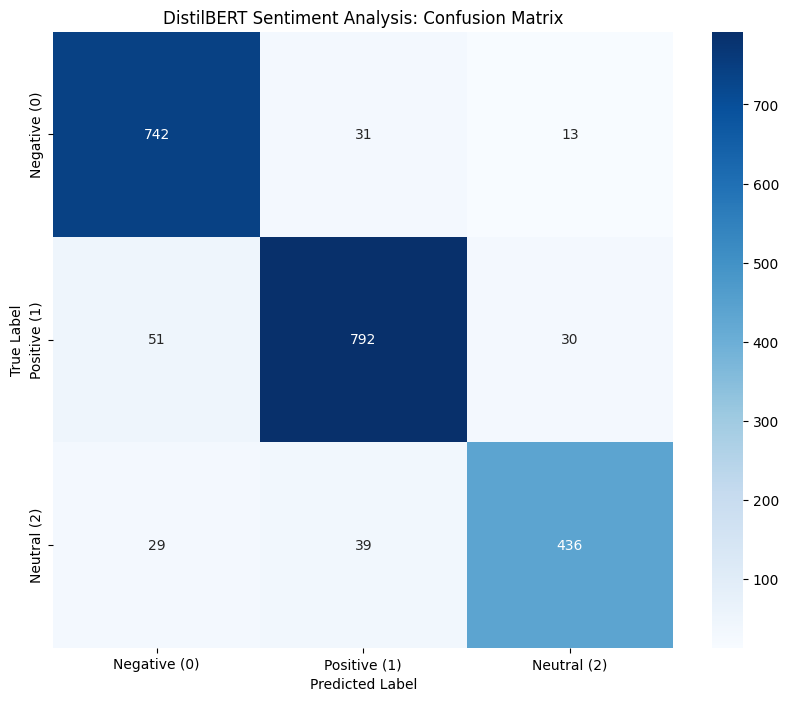

In [488]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#  Get predictions from the trainer
test_results = trainer.predict(val_dataset)
y_true = test_results.label_ids
y_pred = test_results.predictions.argmax(-1)

#  Generating the confusion matrix
cm = confusion_matrix(y_true, y_pred)

#Defining the class labels based on dfr vader_label function:
labels = ['Negative (0)', 'Positive (1)', 'Neutral (2)']

# Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, 
            yticklabels=labels)

plt.title('DistilBERT Sentiment Analysis: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Roberta Model

In [20]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_text"],
    df["sentiment_label"],
    test_size=0.3,
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5
)

In [21]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

## Encoding

In [22]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

## Creating Class Dataset

In [23]:
class TweetDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [25]:
from transformers import RobertaForSequenceClassification
model = RobertaForSequenceClassification.from_pretrained(
    "cardiffnlp/twitter-roberta-base-sentiment",
    num_labels=3
)

In [1]:
##Tuning

In [26]:
learning_rate = 2e-5
batch_size = 16
epochs = 3
weight_decay = 0.01

In [31]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import torch.nn.functional as F
import torch

def compute_metrics(pred):
    labels = pred.label_ids
    logits = pred.predictions
    
    # predictions for Accuracy, F1, Precision, and Recall
    preds = logits.argmax(-1) 
    
    # Probabilities for AUC-ROC
    probs = F.softmax(torch.from_numpy(logits), dim=-1).numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="macro"),
        "recall": recall_score(labels, preds, average="macro"),
        "f1": f1_score(labels, preds, average="macro"),
        "auc_roc": roc_auc_score(labels, probs, multi_class='ovr')
    }

In [32]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [33]:
trainer.train()

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc Roc
1,0.155500,0.388213,0.895126,0.892041,0.887054,0.889252,0.975821
2,0.184500,0.388544,0.902529,0.901272,0.894860,0.897782,0.977050
3,0.083300,0.479067,0.901295,0.899406,0.895572,0.897134,0.976110


C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=1419, training_loss=0.1746729051167903, metrics={'train_runtime': 27582.5583, 'train_samples_per_second': 0.822, 'train_steps_per_second': 0.051, 'total_flos': 1492050413581056.0, 'train_loss': 0.1746729051167903, 'epoch': 3.0})

In [34]:
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)
test_labels = predictions.label_ids 

# Metric Calculations
acc = accuracy_score(test_labels, y_pred)
prec = precision_score(test_labels, y_pred, average="macro")
rec = recall_score(test_labels, y_pred, average="macro")
f1 = f1_score(test_labels, y_pred, average="macro")

# Print Summary
print(f"Roberta Results")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

#Detailed
print("\nDetailed Classification Report:")
print(classification_report(test_labels, y_pred))

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Roberta Results
Accuracy:  0.8951
Precision: 0.8920
Recall:    0.8871
F1 Score:  0.8893

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       615
           1       0.90      0.89      0.90       646
           2       0.88      0.84      0.86       360

    accuracy                           0.90      1621
   macro avg       0.89      0.89      0.89      1621
weighted avg       0.89      0.90      0.89      1621



## Printing the evalution report

In [ ]:
# Extracting true labels and predictions from the trainer
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)
y_true = predictions.label_ids

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

In [59]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(test_labels, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[394  97  91]
 [ 98 486  89]
 [ 86  75 202]]


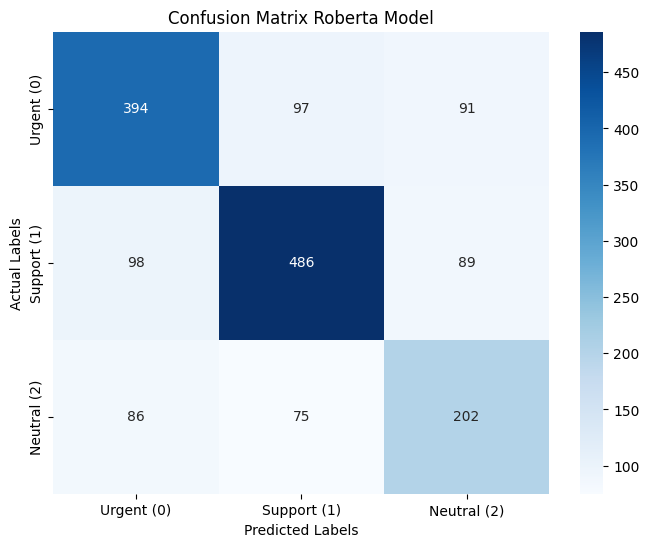

In [200]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ['Urgent (0)', 'Support (1)', 'Neutral (2)']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix Roberta Model')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

## AUC-ROC Curve

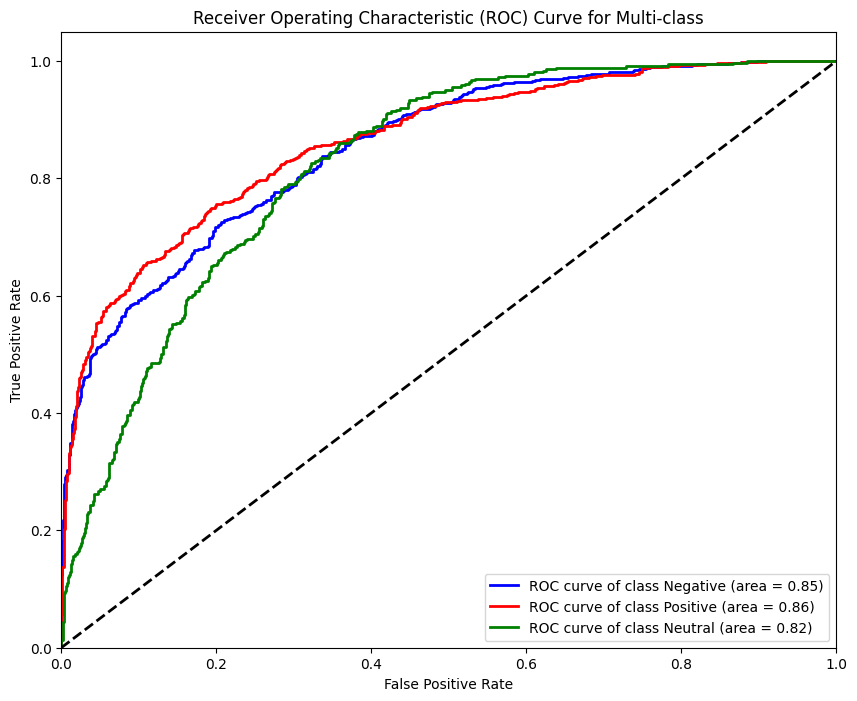

In [172]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import torch

# Convert logits to probabilities
logits = torch.from_numpy(predictions.predictions)
probs = F.softmax(logits, dim=-1).numpy()

# Binarize labels 
n_classes = 3
y_test_binarized = label_binarize(test_labels, classes=[0, 1, 2])
target_names = ['Negative', 'Positive', 'Neutral']
colors = ['blue', 'red', 'green']

# Plotting
plt.figure(figsize=(10, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of class {target_names[i]} (area = {roc_auc:.2f})')

# diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.show()

# BILSTM 

# Train test Split

In [68]:

# clean_text is a list of strings
text_list = df_filtered["clean_text"].tolist()

# Tokenize using the Hugging Face way
encodings = tokenizer(
    text_list, 
    truncation=True, 
    padding='max_length', 
    max_length=100, 
    return_tensors='np' 
)

# X is now dfr input IDs
X = encodings['input_ids']


y = df_filtered["sentiment_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [69]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Prepare text for BiLSTM 
max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["clean_text"])

X = tokenizer.texts_to_sequences(df["clean_text"])
X = pad_sequences(X, maxlen=max_len)

label_map = {"not_relevant":0,"relevant":1}
df["label_num"] = df["label"].map(label_map)

y = df["label_num"]

# Train test spli
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

In [70]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

## Build BiLSTM model

In [71]:
from tensorflow.keras import regularizers

In [35]:
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

#  Configuration Parameters
embedding_dim = 100 
max_words = 20000 
max_len = 100

#  Pre-trained GloVe Embeddings  
embeddings_index = {}
try:
    # setting encoding='utf-8' 
    with open('glove.6B.100d.txt', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            if len(values) > 1:
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
    print(f"Successfully loaded {len(embeddings_index)} word vectors.")
except FileNotFoundError:
    print("We have error, glove.6B.100d.txt not found")

#  Creating the Embedding Matrix
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

#   BiLSTM Architecture
model = Sequential([
    
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False  # Freeze GloVe weights
    ),
    # Bidirectional layer for context
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.5), 
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') 
])

# Compile the Model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Build and Summary to verify shapes
model.build(input_shape=(None, max_len))
model.summary()



Successfully loaded 400000 word vectors.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,251,009 (8.59 MB)

 Trainable params: 251,009 (980.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [73]:
## Train model

In [36]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2)

In [38]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train = tokenizer.texts_to_sequences(train_texts)
X_val = tokenizer.texts_to_sequences(val_texts)

X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_val = pad_sequences(X_val, maxlen=max_len, padding='post')

In [75]:
model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.6966 - loss: 0.5873 - val_accuracy: 0.7254 - val_loss: 0.5568
Epoch 2/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - accuracy: 0.7266 - loss: 0.5494 - val_accuracy: 0.7439 - val_loss: 0.5456
Epoch 3/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.7370 - loss: 0.5353 - val_accuracy: 0.7404 - val_loss: 0.5415
Epoch 4/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.7413 - loss: 0.5217 - val_accuracy: 0.7277 - val_loss: 0.5466
Epoch 5/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.7518 - loss: 0.5106 - val_accuracy: 0.7126 - val_loss: 0.5569


## Evaluation

In [82]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

# Generate predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
Accuracy:  0.7275
Precision: 0.7717
Recall:    0.6156
F1 Score:  0.6849

Full Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.83      0.76      1120
           1       0.77      0.62      0.68      1038

    accuracy                           0.73      2158
   macro avg       0.74      0.72      0.72      2158
weighted avg       0.73      0.73      0.72      2158



In [81]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.7944888865951005


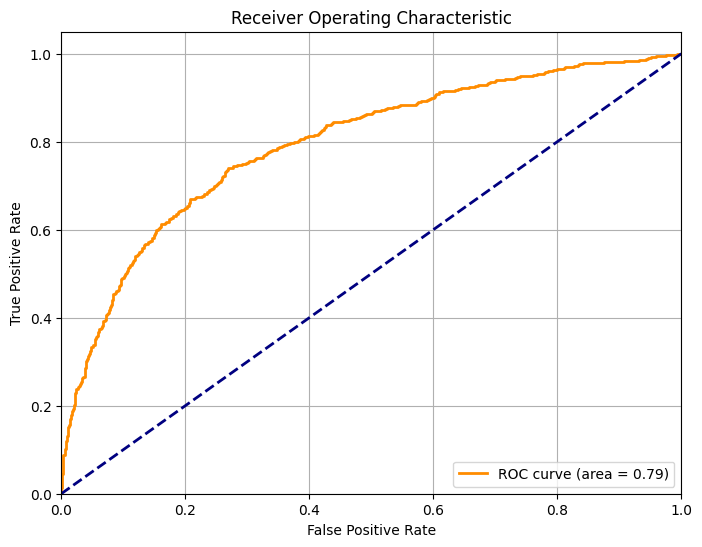

In [176]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

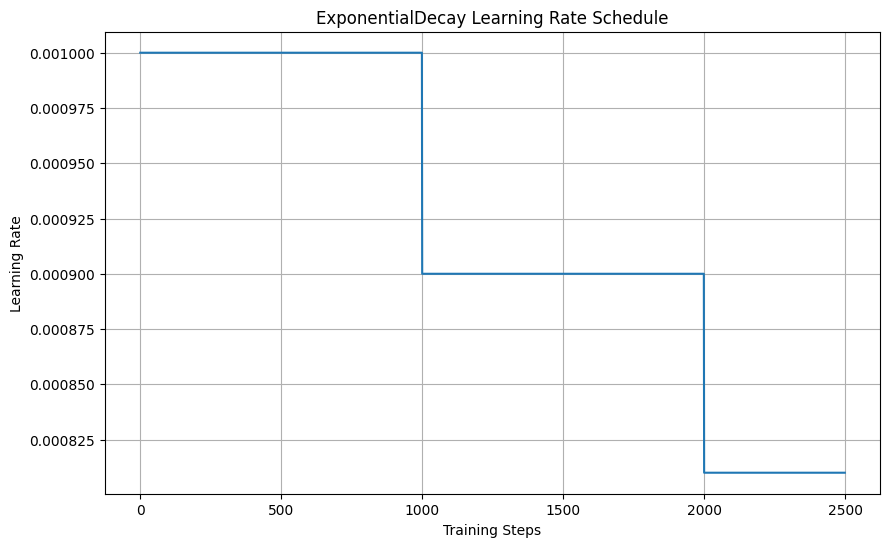

In [84]:
import tensorflow as tf
import matplotlib.pyplot as plt

# learning rate schedule 
initial_learning_rate = 0.001
decay_steps = 1000
decay_rate = 0.9

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True)

# learning rate
epochs = 50
hypothetical_steps_per_epoch = 50 
total_steps = epochs * hypothetical_steps_per_epoch

learning_rates = []
for step in range(total_steps):
    learning_rates.append(lr_schedule(step).numpy())

# Ploting the learning rate schedule
plt.figure(figsize=(10, 6))
plt.plot(learning_rates)
plt.title('ExponentialDecay Learning Rate Schedule')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.show()


### Confusion Metrics

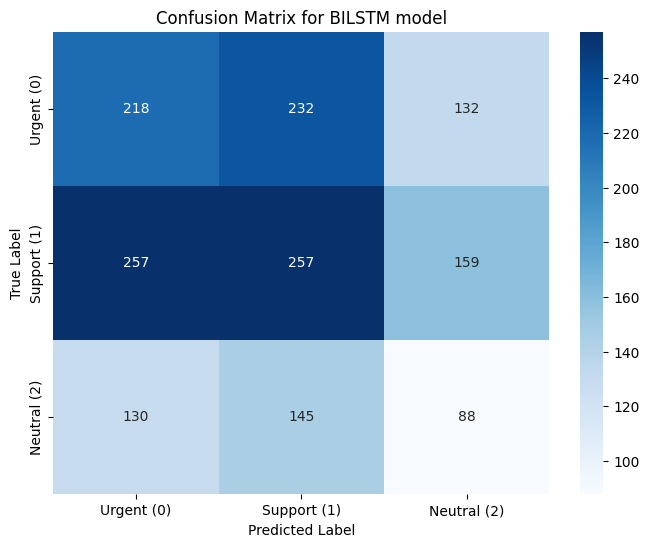

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred)

labels = ['Urgent (0)', 'Support (1)', 'Neutral (2)']

plt.figure(figsize=(8, 6))
# Create the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)2.

plt.title('Confusion Matrix for BILSTM model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# CNN Model Sentimental Analysis

In [152]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["clean_text"],
    df["sentiment_label"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment_label"]
)

In [32]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

X_train = tokenizer.texts_to_sequences(train_texts)
X_val = tokenizer.texts_to_sequences(val_texts)

X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_val = pad_sequences(X_val, maxlen=max_len, padding='post')

In [154]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),

    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),

    Dropout(0.5),
    Dense(64, activation='relu'),

    Dense(3, activation='softmax')  # classes 
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\ThinkPad\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_4               │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Embedding
from tensorflow.keras.models import Sequential

In [155]:
history = model.fit(
    X_train,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, val_labels)
)

Epoch 1/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6280 - loss: 0.7758 - val_accuracy: 0.8360 - val_loss: 0.4419
Epoch 2/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8978 - loss: 0.2990 - val_accuracy: 0.8675 - val_loss: 0.3877
Epoch 3/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9569 - loss: 0.1450 - val_accuracy: 0.8689 - val_loss: 0.4308
Epoch 4/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9754 - loss: 0.0826 - val_accuracy: 0.8647 - val_loss: 0.4896
Epoch 5/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9883 - loss: 0.0442 - val_accuracy: 0.8638 - val_loss: 0.5659


In [156]:
## Prediction

In [157]:
import numpy as np

y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [158]:
## Evalution

In [159]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

accuracy = accuracy_score(val_labels, y_pred)
precision = precision_score(val_labels, y_pred, average='weighted')
recall = recall_score(val_labels, y_pred, average='weighted')
f1 = f1_score(val_labels, y_pred, average='weighted')

# ROC-AUC (multi-class)
import pandas as pd
roc_auc = roc_auc_score(
    pd.get_dummies(val_labels),
    y_pred_probs,
    multi_class='ovr'
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:\n")
print(classification_report(val_labels, y_pred))

Accuracy: 0.8637627432808156
Precision: 0.8636327004476334
Recall: 0.8637627432808156
F1 Score: 0.8636015876267479
ROC-AUC: 0.956728605700898

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88       785
           1       0.87      0.89      0.88       870
           2       0.83      0.81      0.82       503

    accuracy                           0.86      2158
   macro avg       0.86      0.86      0.86      2158
weighted avg       0.86      0.86      0.86      2158



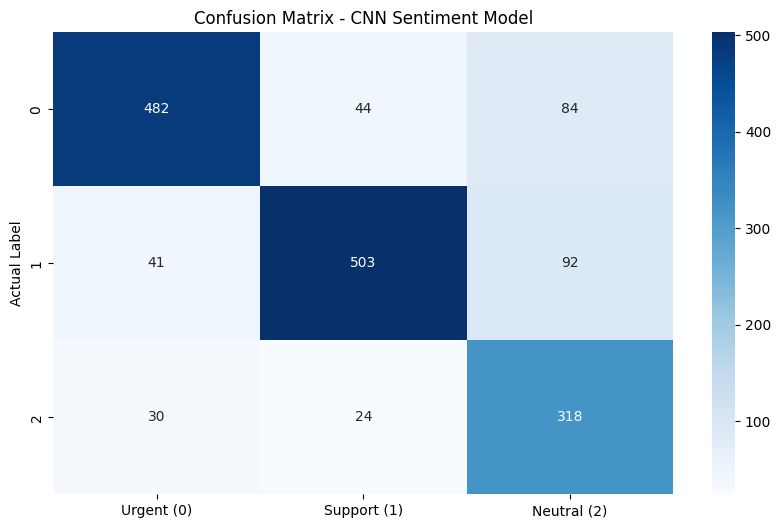

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(val_labels, y_pred)

# Convert to DataFrame for better labeling
cm_df = pd.DataFrame(
    cm,
    
    columns=['Urgent (0)', 'Support (1)', 'Neutral (2)']
)

# Plot 
plt.figure(figsize=(10, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - CNN Sentiment Model')
plt.ylabel('Actual Label')

plt.show()

# Sentimental Analysis Logistic regression

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Convert text to numerical vectors
X_train_vec = vectorizer.fit_transform(train_texts)
X_val_vec = vectorizer.transform(val_texts)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)} words")

Vocabulary size: 5000 words


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


base_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#   hyperparameter grid to search

param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

#  Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', 
    n_jobs=-1,          #
    verbose=1           
)

# Runing the tuning process on dfr vectorized training data
print("Starting Hyperparameter Tuning. This may take a minute...\n")
grid_search.fit(X_train_vec, train_labels)


print(f"\ Tuning Complete")
print(f"Best Hyperparameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# Save the best model automatically found by the grid search
best_lr_model = grid_search.best_estimator_

Starting Hyperparameter Tuning. This may take a minute...


<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\ '
C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_27736\3848435973.py:31: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Tuning Complete")



Fitting 5 folds for each of 7 candidates, totalling 35 fits
\ Tuning Complete
Best Hyperparameters found: {'C': 10.0}
Best Cross-Validation F1-Score: 0.7987


In [24]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
lr_model = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
print("Training Logistic Regression model...")
lr_model.fit(X_train_vec, train_labels)
print("Training complete!")

Training Logistic Regression model...
Training complete!


In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on the validation set
y_pred = lr_model.predict(X_val_vec)

# e Classification Report
print("\n Logistic Regression Classification Report")
print(classification_report(val_labels, y_pred, target_names=["Urgent", "Support", "Neutral"]))


 Logistic Regression Classification Report
              precision    recall  f1-score   support

      Urgent       0.88      0.78      0.83       785
     Support       0.89      0.81      0.85       872
     Neutral       0.65      0.86      0.74       503

    accuracy                           0.81      2160
   macro avg       0.81      0.82      0.80      2160
weighted avg       0.83      0.81      0.82      2160



In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# both class predictions and probabilities

y_pred = lr_model.predict(X_val_vec)

# 'y_score' 
y_score = lr_model.predict_proba(X_val_vec)

#  Binarize the labels d
lb = LabelBinarizer()
lb.fit(val_labels)
val_labels_bin = lb.transform(val_labels)

#  Calculate individual metrics
accuracy = accuracy_score(val_labels, y_pred)
precision = precision_score(val_labels, y_pred, average='weighted')
recall = recall_score(val_labels, y_pred, average='weighted')
f1 = f1_score(val_labels, y_pred, average='weighted')

# Calculate Weighted AUC-ROC
auc_roc = roc_auc_score(val_labels_bin, y_score, multi_class='ovr', average='weighted')

# Print Evaluation Metrics
print("\n Logistic Regression Individual Evaluation Metrics ")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")


 Logistic Regression Individual Evaluation Metrics 
Accuracy:  0.8116
Precision: 0.8288
Recall:    0.8116
F1-Score:  0.8152
AUC-ROC:   0.9388


## Confusion Metrics

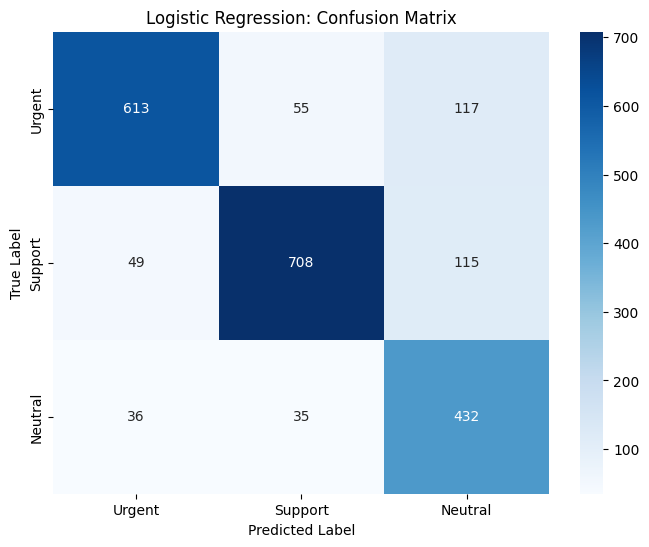

In [30]:
#  Generate and Plot the Confusion Matrix
cm = confusion_matrix(val_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Urgent", "Support", "Neutral"], 
            yticklabels=["Urgent", "Support", "Neutral"])

plt.title('Logistic Regression: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

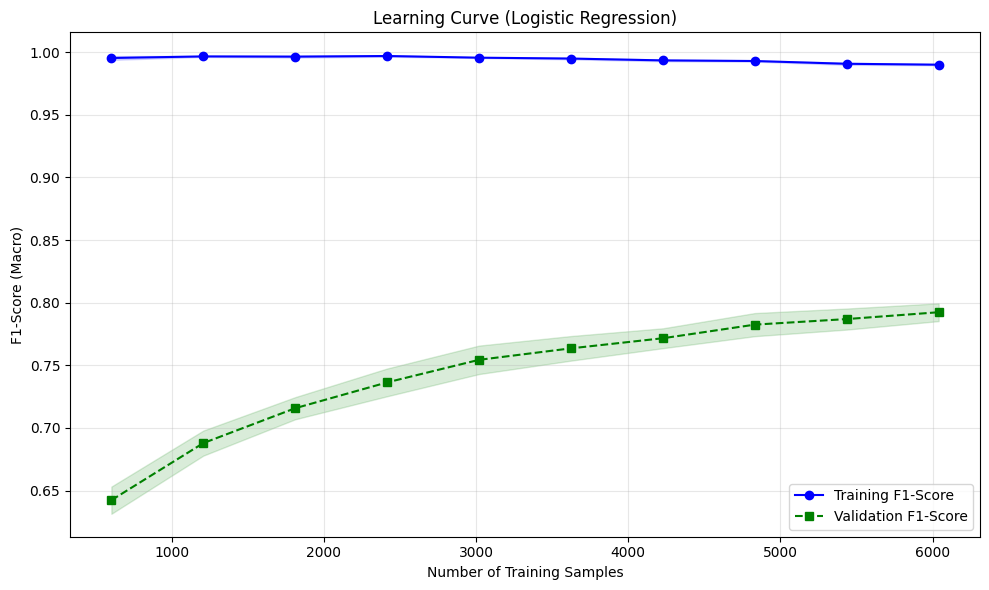

In [195]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve


estimator = best_lr_model 


train_sizes, train_scores, val_scores = learning_curve(
    estimator=estimator, 
    X=X_train_vec, 
    y=train_labels, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,          
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation 
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

#  results
plt.figure(figsize=(10, 6))

# Plot the training scores
plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Training F1-Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

# validation scores
plt.plot(train_sizes, val_mean, color='green', linestyle='--', marker='s', label='Validation F1-Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

# Graph formatting
plt.title('Learning Curve (Logistic Regression)')
plt.xlabel('Number of Training Samples')
plt.ylabel('F1-Score (Macro)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_ladft()
plt.show()

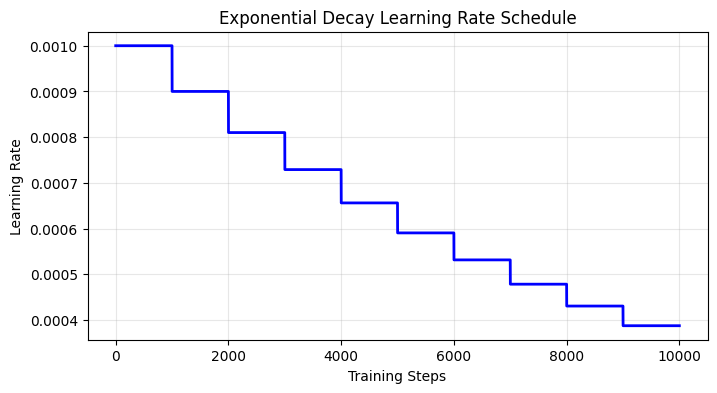

In [196]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Learning Rate Schedule
initial_learning_rate = 0.001
decay_steps = 1000
decay_rate = 0.9

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=True  # True = drops in steps. False = smooth continuous curve.
)

# model's optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


#  Generate and Plot the Schedule 
steps = np.arange(0, 10000)
lrs = [lr_schedule(step).numpy() for step in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, lrs, color='blue', lw=2)
plt.title('Exponential Decay Learning Rate Schedule')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.show()